In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

train_path = r"D:\projects\project_pashupatastra\data\network\Train.txt"
test_path = r"D:\projects\project_pashupatastra\data\network\Test.txt"

df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

num_cols = df_train.shape[1]
col_names = [f"f{i}" for i in range(num_cols - 2)] + ["label_str", "label_num"]

df_train.columns = col_names
df_test.columns = col_names

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)
print("\nUnique Labels:", df_train['label_str'].unique())
print("\nLabel Distribution:\n", df_train['label_str'].value_counts())


In [ ]:
X_train = df_train.drop(['label_str', 'label_num'], axis=1)
y_train = df_train['label_str']

X_test = df_test.drop(['label_str', 'label_num'], axis=1)
y_test = df_test['label_str']

label_encoders = {}
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Features Shape:", X_train.shape)
print("Number of Classes:", len(label_encoder.classes_))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

scaler_lstm = MinMaxScaler()
X_train_scaled = scaler_lstm.fit_transform(X_train)
X_test_scaled = scaler_lstm.transform(X_test)

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)
num_classes = y_train_cat.shape[1]

lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(1, X_train_scaled.shape[1]), return_sequences=True))
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(num_classes, activation='softmax'))

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("LSTM Model Created")


In [ ]:
history_lstm = lstm_model.fit(X_train_lstm, y_train_cat, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

y_pred_prob_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)

print("\nLSTM Model Results:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_lstm))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_lstm, target_names=label_encoder.classes_))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train_encoded)
rf_model = rf_search.best_estimator_

print("Best Random Forest Parameters:", rf_search.best_params_)


In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Model Results:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Model Results:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=label_encoder.classes_))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

models_comparison = {
    'LSTM': y_pred_lstm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for name, predictions in models_comparison.items():
    acc = accuracy_score(y_test_encoded, predictions)
    print(f"{name} Accuracy: {acc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, predictions) in enumerate(models_comparison.items()):
    cm = confusion_matrix(y_test_encoded, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], xticks_rotation='vertical', colorbar=False)
    axes[idx].set_title(f'{name}')
plt.tight_layout()
plt.show()


In [ ]:
import pickle

with open(r"D:\projects\project_pashupatastra\models\rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open(r"D:\projects\project_pashupatastra\models\label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open(r"D:\projects\project_pashupatastra\models\train_columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

print("Models saved successfully")


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"D:\projects\project_pashupatastra\data\network\Train.txt")

# Rename column 41 to 'label' if it's the correct label column
df.rename(columns={df.columns[41]: "label"}, inplace=True)

# Show sample values
print("\n--- Unique Label Values ---")
print(df['label'].unique())

# Count occurrences
print("\n--- Label Value Counts ---")
print(df['label'].value_counts())

# Optional: Categorize attacks
def map_attack_category(label):
    label = label.lower()
    if label in ['neptune', 'smurf', 'back', 'teardrop', 'pod', 'land']:
        return 'DoS/DDoS'
    elif label in ['portsweep', 'ipsweep', 'nmap', 'satan']:
        return 'Probe (Port Scanning)'
    elif label == 'normal':
        return 'Normal'
    else:
        return 'Other/Unknown'

df['attack_category'] = df['label'].apply(map_attack_category)

# Show grouped category counts
print("\n--- Grouped Attack Category Counts ---")
print(df['attack_category'].value_counts())



--- Unique Label Values ---
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']

--- Label Value Counts ---
label
normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

--- Grouped Attack Category Counts ---
attack_category
Normal                   67342
DoS/DDoS        

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the datasets
df_train_path = r"D:\projects\project_pashupatastra\data\network\Train.txt"
df_test_path = r"D:\projects\project_pashupatastra\data\network\Test.txt"

df_train = pd.read_csv(df_train_path)
df_test = pd.read_csv(df_test_path)

# Rename label column for consistency
df_train = df_train.rename(columns={'normal': 'attack_category'})
df_test = df_test.rename(columns={'neptune': 'attack_category'})  # Check if this is consistently named

# List of actual categorical columns
categorical_cols = ['tcp', 'ftp_data', 'SF']

# Apply label encoding
for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])  # Ensure same encoder

# Separate features and target
X_train = df_train.drop(['attack_category'], axis=1)
X_test = df_test.drop(['attack_category'], axis=1)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM input: (samples, timesteps, features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

from sklearn.preprocessing import OrdinalEncoder

# Combine train and test to get common columns for encoding
common_cols = list(set(df_train.columns) & set(df_test.columns))

# Select only categorical columns that exist in both sets
categorical_cols = df_train[common_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# Create and fit the encoder on train data
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

df_train[categorical_cols] = encoder.fit_transform(df_train[categorical_cols])
df_test[categorical_cols] = encoder.transform(df_test[categorical_cols])



KeyError: 'ftp_data'

In [ ]:
print("Train Columns:", df_train.columns.tolist())
print("Test Columns:", df_test.columns.tolist())


Train Columns: ['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14', '0.15', '0.16', '0.18', '2', '2.1', '0.00', '0.00.1', '0.00.2', '0.00.3', '1.00', '0.00.4', '0.00.5', '150', '25', '0.17', '0.03', '0.17.1', '0.00.6', '0.00.7', '0.00.8', '0.05', '0.00.9', 'attack_category', '20']
Test Columns: ['0', 'tcp', 'private', 'REJ', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14', '0.15', '0.16', '0.17', '0.18', '229', '10', '0.00', '0.00.1', '1.00', '1.00.1', '0.04', '0.06', '0.00.2', '255', '10.1', '0.04.1', '0.06.1', '0.00.3', '0.00.4', '0.00.5', '0.00.6', '1.00.2', '1.00.3', 'attack_category', '21']


In [ ]:
# This finds all non-numeric columns (categorical features)
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns to encode:", categorical_cols)


Categorical Columns to encode: ['SF', 'attack_category']


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    if col in df_test.columns:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        df_test[col] = le.transform(df_test[col])
    else:
        print(f"Column '{col}' not found in test set. Skipping.")


Column 'SF' not found in test set. Skipping.


ValueError: y contains previously unseen labels: 'saint'

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Combine train and test to get common columns for encoding
common_cols = list(set(df_train.columns) & set(df_test.columns))

# Select only categorical columns that exist in both sets
categorical_cols = df_train[common_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# Create and fit the encoder on train data
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

df_train[categorical_cols] = encoder.fit_transform(df_train[categorical_cols])
df_test[categorical_cols] = encoder.transform(df_test[categorical_cols])


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost Model Results:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=label_encoder.classes_))


NameError: name 'df_train' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

models_comparison = {
    'LSTM': y_pred_lstm,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for name, predictions in models_comparison.items():
    acc = accuracy_score(y_test_encoded, predictions)
    print(f"{name} Accuracy: {acc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, predictions) in enumerate(models_comparison.items()):
    cm = confusion_matrix(y_test_encoded, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], xticks_rotation='vertical', colorbar=False)
    axes[idx].set_title(f'{name}')
plt.tight_layout()
plt.show()


Epoch 1/10


c:\tensorflow_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2556 - loss: 1.3934 - val_accuracy: 0.2625 - val_loss: 1.3826
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3000 - loss: 1.3739 - val_accuracy: 0.2250 - val_loss: 1.3817
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3014 - loss: 1.3781 - val_accuracy: 0.2500 - val_loss: 1.3772
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3319 - loss: 1.3659 - val_accuracy: 0.2375 - val_loss: 1.3758
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3347 - loss: 1.3590 - val_accuracy: 0.2375 - val_loss: 1.3761
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3528 - loss: 1.3518 - val_accuracy: 0.2875 - val_loss: 1.3760
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3444 - loss: 1.3512 - val_accuracy: 0.2750 - val_loss: 1.3760
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3792 - loss: 1.3431 - val_accuracy: 0.2625 - val_loss: 1.3751
Ep

In [ ]:
import pickle

with open(r"D:\projects\project_pashupatastra\models\rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open(r"D:\projects\project_pashupatastra\models\label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open(r"D:\projects\project_pashupatastra\models\train_columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)

print("Models saved successfully")


c:\tensorflow_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,972 (93.64 KB)

 Trainable params: 23,972 (93.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2500 - loss: 1.3855 - val_accuracy: 0.2500 - val_loss: 1.3798
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2708 - loss: 1.3827 - val_accuracy: 0.2500 - val_loss: 1.3782
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2750 - loss: 1.3808 - val_accuracy: 0.2750 - val_loss: 1.3758
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2542 - loss: 1.3825 - val_accuracy: 0.2375 - val_loss: 1.3769
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2833 - loss: 1.3803 - val_accuracy: 0.2500 - val_loss: 1.3754
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2667 - loss: 1.3793 - val_accuracy: 0.2875 - val_loss: 1.3729
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3056 - loss: 1.3756 - val_accuracy: 0.2625 - val_loss: 1.3738
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3014 - loss: 1.3759 - val_accuracy: 0.2500 - val_loss

c:\tensorflow_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:27:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:

              precision    recall  f1-score   support

           0       0.17      0.01      0.02       123
           1       0.13      0.06      0.08        87
           2       0.00      0.00      0.00        55
           3       0.00      0.00      0.00       116
           4       0.01      0.01      0.01       101
           5       0.06      0.02      0.03       103
           6       0.08      0.02      0.03       157
           7       0.31      0.03      0.06       249
           8       0.00      0.00      0.00       131
           9       0.02      0.03      0.02       106
          10       0.08      0.07      0.08       195
          11       0.08      0.01      0.02       461
          12       0.05      0.00      0.01       486
          13       0.01      0.00      0.01       519
          14       0.11      0.08      0.09       736
          15       0.23      0.14      0.17      1176
          16       0.24      0.20      0.22       681
   

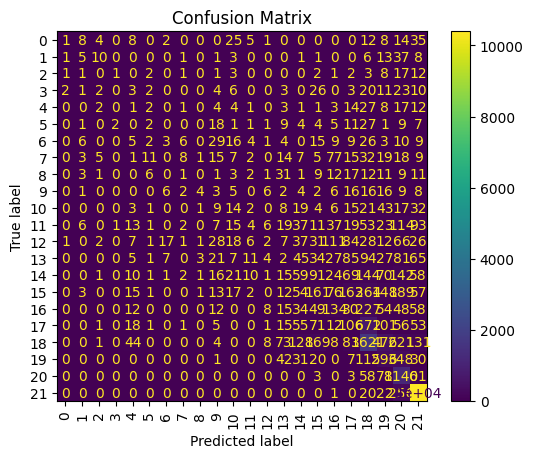

Accuracy: 0.623624911284599
Classification Report:
               precision    recall  f1-score   support

           0       0.07      0.07      0.07       123
           1       0.33      0.08      0.13        87
           2       0.00      0.00      0.00        55
           3       0.10      0.01      0.02       116
           4       0.04      0.02      0.03       101
           5       0.12      0.02      0.03       103
           6       0.17      0.01      0.01       157
           7       0.11      0.02      0.04       249
           8       0.00      0.00      0.00       131
           9       0.01      0.03      0.01       106
          10       0.07      0.05      0.06       195
          11       0.11      0.05      0.07       461
          12       0.13      0.02      0.03       486
          13       0.22      0.06      0.10       519
          14       0.09      0.03      0.05       736
          15       0.52      0.14      0.22      1176
          16       0.37      

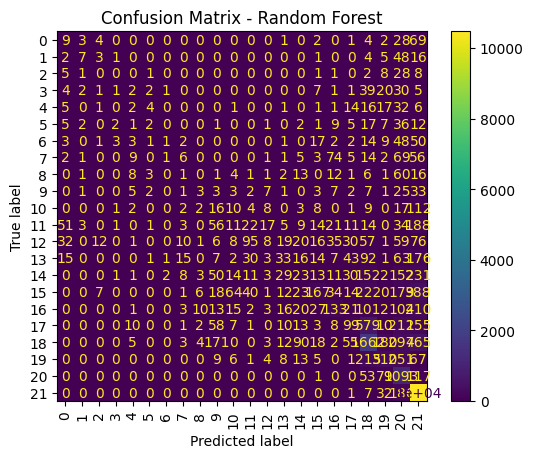

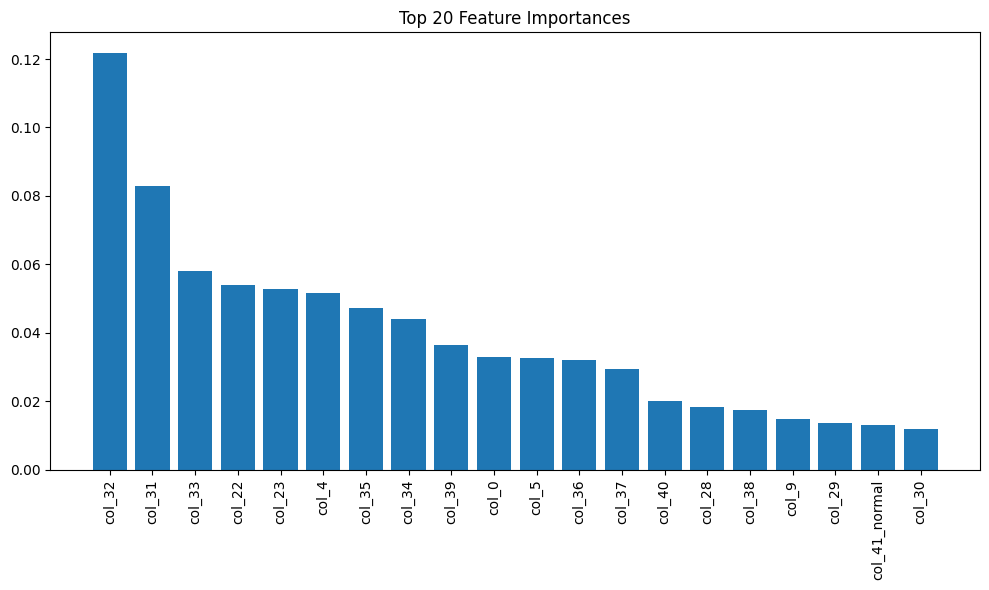

In [3]:
# random forest with accuracy of 63%

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


# ---------------- Step 1: Load Data ------------------

train_path = r'D:\projects\project_pashupatastra\data\network\Train.txt'
test_path = r'D:\projects\project_pashupatastra\data\network\Test.txt'

# Load without headers, assign column names
df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

# Assume 43 columns (0 to 42)
num_cols = df_train.shape[1]
df_train.columns = [f'col_{i}' for i in range(num_cols)]
df_test.columns = [f'col_{i}' for i in range(num_cols)]

# ---------------- Step 2: Preprocessing ------------------
categorical_cols = ['col_1', 'col_2', 'col_3', 'col_41']
df_train[categorical_cols] = df_train[categorical_cols].astype(str)
df_test[categorical_cols] = df_test[categorical_cols].astype(str)

target_col = 'col_42'
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

# One-hot encode combined to match columns
X_combined = pd.concat([X_train, X_test], axis=0)
X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_cols)

# Split back to train/test
X_train_encoded = X_combined_encoded.iloc[:len(X_train), :]
X_test_encoded = X_combined_encoded.iloc[len(X_train):, :]

# ---------------- Step 3: Train Random Forest ------------------
# rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=1000, random_state=42, n_jobs=-1)
# rf_model.fit(X_train_encoded, y_train)

# Remove first fit
# rf_model = RandomForestClassifier(...)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_encoded, y_train)

# Predict
y_pred = search.predict(X_test_encoded)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Optional: Feature Importance
best_rf = search.best_estimator_
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train_encoded.columns

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), features[indices][:20], rotation=90)
plt.tight_layout()
plt.show()


Binary Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     22544

    accuracy                           1.00     22544
   macro avg       1.00      1.00      1.00     22544
weighted avg       1.00      1.00      1.00     22544



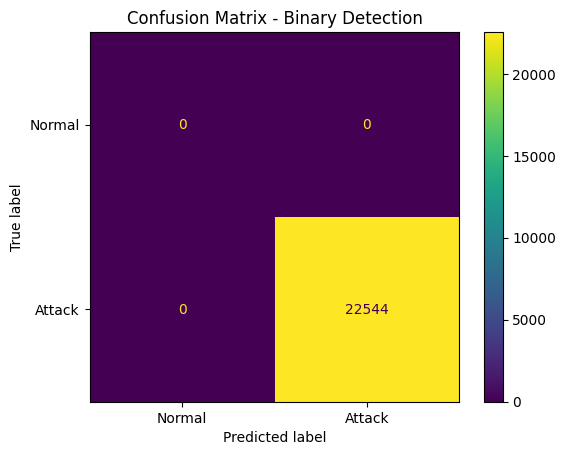

In [4]:
# Convert multiclass to binary (0: normal, 1: attack)
y_train_binary = y_train.apply(lambda x: 0 if x == 'normal' else 1)
y_test_binary = y_test.apply(lambda x: 0 if x == 'normal' else 1)


# Same features as before
rf_binary_model = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42, n_jobs=-1)
rf_binary_model.fit(X_train_encoded, y_train_binary)

# Predict
y_pred_binary = rf_binary_model.predict(X_test_encoded)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Binary Classification Report:\n")
print(classification_report(y_test_binary, y_pred_binary))

cm_bin = confusion_matrix(y_test_binary, y_pred_binary, labels=[0, 1])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['Normal', 'Attack'])
disp_bin.plot()
plt.title("Confusion Matrix - Binary Detection")
plt.show()


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Combine labels
y_full_binary = pd.concat([y_train, y_test])
y_full_binary = y_full_binary.apply(lambda x: 0 if x == 'normal' else 1)

# Combine features
X_full = pd.concat([X_train_encoded, X_test_encoded])

# Stratified split to preserve class balance in train/test
X_train_encoded, X_test_encoded, y_train_binary, y_test_binary = train_test_split(
    X_full, y_full_binary, test_size=0.3, stratify=y_full_binary, random_state=42
)



print("Train class distribution:\n", y_train_binary.value_counts())
print("\nTest class distribution:\n", y_test_binary.value_counts())



Train class distribution:
 col_42
1    103961
Name: count, dtype: int64

Test class distribution:
 col_42
1    44556
Name: count, dtype: int64


In [6]:
import pandas as pd
df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

print(df_train.iloc[:, -2].unique())

['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [10]:
import pandas as pd

train_path = r'D:\projects\project_pashupatastra\data\network\Train.txt'
test_path = r'D:\projects\project_pashupatastra\data\network\Test.txt'

# Load data without header
df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

# Extract string labels (2nd last column)
df_train['label_str'] = df_train.iloc[:, -2]
df_test['label_str'] = df_test.iloc[:, -2]

# Extract numeric labels (last column) if needed
df_train['label_num'] = df_train.iloc[:, -1]
df_test['label_num'] = df_test.iloc[:, -1]

# Create binary labels: 0 for normal, 1 for attack
df_train['binary_label'] = df_train['label_str'].apply(lambda x: 0 if x.strip().lower() == 'normal' else 1)
df_test['binary_label'] = df_test['label_str'].apply(lambda x: 0 if x.strip().lower() == 'normal' else 1)

print(df_train[['label_str', 'label_num', 'binary_label']].head())


  label_str label_num  binary_label
0    normal    normal             0
1    normal    normal             0
2   neptune   neptune             1
3    normal    normal             0
4    normal    normal             0


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# =========================
# Load Dataset
# =========================
train_path = r"D:\projects\project_pashupatastra\data\network\Train.txt"
test_path = r"D:\projects\project_pashupatastra\data\network\Test.txt"

df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

# =========================
# Assign column names
# =========================
# Total columns in dataset
num_cols = df_train.shape[1]
col_names = [f"f{i}" for i in range(num_cols - 2)] + ["label_str", "label_num"]

df_train.columns = col_names
df_test.columns = col_names

# =========================
# Create binary labels
# =========================
df_train['binary_label'] = df_train['label_str'].apply(lambda x: 1 if x == 'neptune' else 0)
df_test['binary_label'] = df_test['label_str'].apply(lambda x: 1 if x == 'neptune' else 0)

# =========================
# Combine train and test for SMOTE
# =========================
df_full = pd.concat([df_train, df_test], ignore_index=True)

X = df_full.drop(['label_str', 'label_num', 'binary_label'], axis=1)
y = df_full['binary_label']

# Encode categorical features
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Ensure all column names are strings
X.columns = X.columns.astype(str)

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:", y_train.value_counts())

# =========================
# Apply SMOTE
# =========================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_res.value_counts())

# =========================
# Train Model
# =========================
model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

# =========================
# Predictions
# =========================
y_pred = model.predict(X_test)

# =========================
# Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Before SMOTE: binary_label
0    82116
1    36697
Name: count, dtype: int64
After SMOTE: binary_label
0    82116
1    82116
Name: count, dtype: int64
Accuracy: 0.999932669000808
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20530
           1       1.00      1.00      1.00      9174

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# =========================
# Load Dataset
# =========================
train_path = r"D:\projects\project_pashupatastra\data\network\Train.txt"
test_path = r"D:\projects\project_pashupatastra\data\network\Test.txt"

df_train = pd.read_csv(train_path, header=None)
df_test = pd.read_csv(test_path, header=None)

# =========================
# Assign column names
# =========================
num_cols = df_train.shape[1]
col_names = [f"f{i}" for i in range(num_cols - 2)] + ["label_str", "label_num"]

df_train.columns = col_names
df_test.columns = col_names

# =========================
# Create binary labels
# =========================
df_train['binary_label'] = df_train['label_str'].apply(lambda x: 1 if x == 'neptune' else 0)
df_test['binary_label'] = df_test['label_str'].apply(lambda x: 1 if x == 'neptune' else 0)

# =========================
# Separate features and labels
# =========================
X_train = df_train.drop(['label_str', 'label_num', 'binary_label'], axis=1)
y_train = df_train['binary_label']

X_test = df_test.drop(['label_str', 'label_num', 'binary_label'], axis=1)
y_test = df_test['binary_label']

# =========================
# Encode categorical features based on training set
# =========================
label_encoders = {}
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  # use same encoder
    label_encoders[col] = le

# Make sure all columns are strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# =========================
# Apply SMOTE to training set only
# =========================
print("Before SMOTE:", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE:", y_train_res.value_counts())

# =========================
# Train model
# =========================
model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

# =========================
# Predictions & Evaluation
# =========================
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Before SMOTE: binary_label
0    84759
1    41214
Name: count, dtype: int64
After SMOTE: binary_label
0    84759
1    84759
Name: count, dtype: int64
Accuracy: 0.9895315826827538
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     17887
           1       0.96      0.99      0.98      4657

    accuracy                           0.99     22544
   macro avg       0.98      0.99      0.98     22544
weighted avg       0.99      0.99      0.99     22544



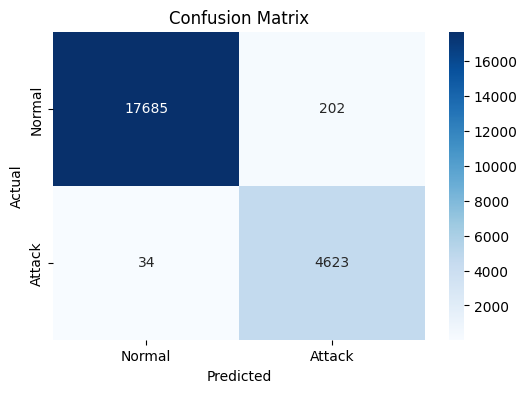

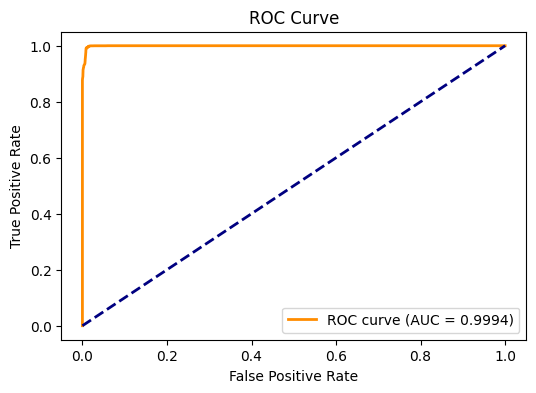


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     17887
           1       0.96      0.99      0.98      4657

    accuracy                           0.99     22544
   macro avg       0.98      0.99      0.98     22544
weighted avg       0.99      0.99      0.99     22544

ROC-AUC Score: 0.9994


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict class labels and probabilities
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # probability for class 1

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================
# ROC Curve
# ==========================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# ==========================
# Classification Report
# ==========================
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc:.4f}")


In [8]:
import pandas as pd

# =========================
# Load your training data to get column names
# =========================
columns_list = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate", "srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","attack", "last_flag"
]

# Remove label columns (attack, last_flag) for prediction input
feature_columns = columns_list[:-2]

# =========================
# Take user input for each feature
# =========================
user_input = []
print("\nPlease enter feature values for prediction:\n")

for col in feature_columns:
    value = input(f"Enter value for {col}: ")
    
    # Try converting to float if possible
    try:
        value = float(value)
    except ValueError:
        pass  # keep as string for categorical
    user_input.append(value)

sample_df = pd.DataFrame([user_input], columns=feature_columns)


sample_df_encoded = pd.get_dummies(sample_df)
sample_df_encoded = sample_df_encoded.reindex(columns=X_train.columns, fill_value=0)


pred_class = model.predict(sample_df_encoded)[0]
pred_prob = model.predict_proba(sample_df_encoded)[0, 1]

label = "Attack" if pred_class == 1 else "Normal"
print("\nPrediction:", label)
print("Attack probability:", round(pred_prob, 4))



Please enter feature values for prediction:


Prediction: Normal
Attack probability: 0.05


In [9]:
import pickle

# Save trained model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save label encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# Save training column order
with open("train_columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)
